# Example 4: Plasmasphere and Ionosphere Tutorial

This tutorial introduces LuPNT's plasma environment tools. These models matter for cislunar GNSS because a signal from an Earth GNSS satellite to a lunar receiver can graze or cross the terrestrial ionosphere and plasmasphere.

The notebook has two parts:

1. sample the GCPM v2.4 electron-density model on a meridional grid;
2. ray-trace one GPS-to-lunar link and compute total electron content (TEC) and dispersive delay.

For a first-order cold-plasma delay, the range delay at carrier frequency $f$ scales approximately as

$$
\Delta\rho_{iono} \approx \frac{40.3}{f^2}\,\mathrm{TEC},
$$

so low-frequency signals and dense plasma paths are affected most strongly.

## 1. Imports and setup

We import LuPNT, NumPy, and plotting tools. The plasma functions are exposed through `pylupnt.plasma` and through top-level bindings for ray tracing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timezone

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt
import pylupnt.plasma as plasma

print("pylupnt plasma base path:", plasma.get_plasma_base_path())
print("RE =", plasma.RE, "km")

[00.01][PyLuPNT] Initializing


pylupnt plasma base path: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/plasma
RE = 6371.0 km


## 2. Simulation epoch

Plasma models are time dependent. LuPNT uses `DateTime` for model queries and seconds since J2000 for orbit propagation and ray tracing, so this section sets both representations of the same epoch.

In [2]:
YEAR, MONTH, DAY, HOUR = 2026, 1, 1, 0

mjd = plasma.gregorian_to_mjd(YEAR, MONTH, DAY, HOUR)
epoch_j2000 = plasma.mjd_to_tj2000(mjd)  # seconds since J2000 (UTC)
dt = plasma.mjd_to_datetime(mjd)  # DateTime for GCPM/IRI queries

# Kp index: use file-based table (returns -1 if data not found; fall back to 2)
kp = plasma.get_kp_index(dt)
if kp < 0:
    kp = 2.0
    print(f"Kp lookup failed — using default Kp = {kp}")

print(f"Epoch : {YEAR}-{MONTH:02d}-{DAY:02d} {HOUR:02d}:00 UTC")
print(f"J2000 : {epoch_j2000:.0f} s")
print(f"Kp    : {kp:.2f}")

# Initialise the IRI electron density model (used inside GCPM)
plasma.set_iri_model("IRI2007")
print("IRI model:", plasma.get_iri_model())

Epoch : 2026-01-01 00:00 UTC
J2000 : 820497627 s
Kp    : 2.00
IRI model: IRI 2007


---
## Part 1: Meridional electron-density slice

`gcpm_v24(dt, r_RE, amlt, alatr, kp)` returns electron and ion densities for the requested magnetic coordinates:

- `r_RE`: geocentric distance in Earth radii;
- `amlt`: magnetic local time in hours;
- `alatr`: magnetic latitude in radians;
- `kp`: geomagnetic activity index.

We sample the noon-midnight meridian plane. The resulting plot shows where the dense plasmasphere sits relative to Earth and why link tangent altitude matters.

In [3]:
RE_km = plasma.RE  # 6371 km
N = 101
R_MAX = 8.0  # Earth radii

x_RE = np.linspace(-R_MAX, R_MAX, N)  # equatorial radial axis: +X = noon, -X = midnight
z_RE = np.linspace(-R_MAX, R_MAX, N)  # along the magnetic (dipole) axis
XX, ZZ = np.meshgrid(x_RE, z_RE)

ne_grid = np.full((N, N), np.nan)

print(f"Sampling GCPM on {N}x{N} meridional grid (r < {R_MAX} Rₑ)...")
for i in range(N):
    for j in range(N):
        x, z = XX[i, j], ZZ[i, j]
        r = np.hypot(x, z)
        if r < 1.01 or r > R_MAX - 0.01:
            continue
        # magnetic latitude in RADIANS (gcpm_v24 expects radians, matching
        # ex_plasma_meridianal_slice.cc): angle above/below the equatorial plane
        alatr = np.arctan2(z, np.abs(x))
        # noon-midnight meridian: +X side = 12 h (noon), -X side = 0 h (midnight)
        amlt = 12.0 if x >= 0 else 0.0
        ne = plasma.gcpm_v24(dt, r, amlt, alatr, kp)[0]
        if ne > 0:
            ne_grid[i, j] = ne

print("Done.")
ne_valid = ne_grid[np.isfinite(ne_grid)]
print(f"ne range: {ne_valid.min():.2e} – {ne_valid.max():.2e} cm⁻³")

Sampling GCPM on 101x101 meridional grid (r < 8.0 Rₑ)...


Done.
ne range: 1.58e-01 – 1.55e+06 cm⁻³


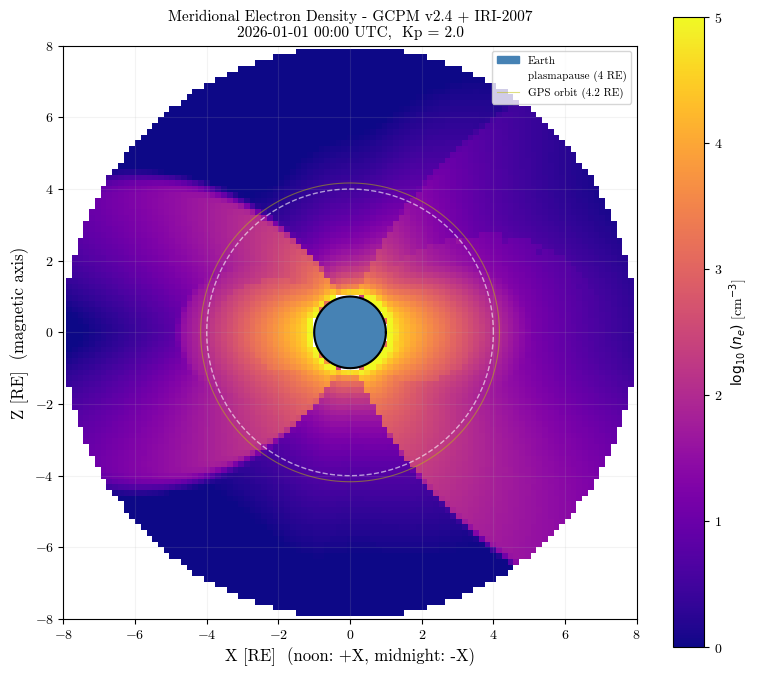

In [4]:
theta_circ = np.linspace(0, 2 * np.pi, 360)

fig, ax = plt.subplots(figsize=(8, 7))

ne_log = np.log10(ne_grid)  # NaN outside domain
im = ax.pcolormesh(XX, ZZ, ne_log, cmap="plasma", vmin=0, vmax=5, shading="auto")
cbar = fig.colorbar(im, ax=ax, label=r"$\log_{10}(n_e)$ [cm$^{-3}$]")

# Earth
ax.fill(
    np.cos(theta_circ), np.sin(theta_circ), color="steelblue", zorder=5, label="Earth"
)
ax.plot(np.cos(theta_circ), np.sin(theta_circ), "k-", lw=1.5, zorder=6)

# Approximate plasmapause at 4 Rₑ
ax.plot(
    4 * np.cos(theta_circ),
    4 * np.sin(theta_circ),
    "w--",
    lw=1.0,
    alpha=0.6,
    label="plasmapause (4 RE)",
)

# GPS MEO orbit
r_gps = 26560 / RE_km
ax.plot(
    r_gps * np.cos(theta_circ),
    r_gps * np.sin(theta_circ),
    "y-",
    lw=0.8,
    alpha=0.5,
    label=f"GPS orbit ({r_gps:.1f} RE)",
)

ax.set_xlabel("X [RE]  (noon: +X, midnight: -X)", fontsize=12)
ax.set_ylabel("Z [RE]  (magnetic axis)", fontsize=12)
ax.set_title(
    f"Meridional Electron Density - GCPM v2.4 + IRI-2007\n"
    f"{YEAR}-{MONTH:02d}-{DAY:02d} {HOUR:02d}:00 UTC,  Kp = {kp:.1f}",
    fontsize=11,
)
ax.set_xlim(-R_MAX, R_MAX)
ax.set_ylim(-R_MAX, R_MAX)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

---
## Part 2: Ray trace from GPS to a lunar receiver

We propagate a representative GPS satellite and a lunar ELFO receiver, then call `trace_ray` along their line of sight. The ray tracer integrates the plasma model along the path and returns TEC plus first-, second-, and third-order ionospheric delay terms.

The orbits match Example 5 so the plasma result can be connected directly to the later GNSS measurement simulation.

In [5]:
# ── Orbital elements ────────────────────────────────────────────────────────
DEG = np.pi / 180

# GPS satellite in circular MEO (a, e, i, RAAN, omega, M) — all angles in rad.
# GPS orbits the Earth, so its position is already Earth-centred ECI.
#
# The mean anomaly is chosen so the GPS is on the FAR side of the Earth from the
# Moon: only then does the GPS→ELFO line of sight graze the plasmasphere (closest
# approach ~1.6 Rₑ at this epoch). With the ELFO at the Moon (~55 Rₑ), a GPS on
# the same side as the Moon would give a line of sight that never dips below the
# 4 Rₑ cutoff — i.e. no plasma crossing and TEC = 0. (M is tuned for the fixed
# 2026-01-01 epoch; change the epoch and this value must be re-tuned.)
M_GPS_GRAZE = 245.0 * DEG
coe_gps = np.array([26560.0, 0.001, 55.0 * DEG, 0.0, 0.0, M_GPS_GRAZE])
gps_sat = plasma.Satellite(1, coe_gps, epoch_j2000, plasma.GM_EARTH)
pos_tx_km = np.array(gps_sat.get_pos())  # Earth-centred ECI [km]

# ELFO receiver: a=6541.4 km, e=0.6, i=56.2°, ω=90° (frozen).
# The ELFO orbits the MOON, so propagate it with the lunar GM to get a
# MOON-CENTRED inertial position, then shift by the Moon's Earth-relative
# position to express it in the same Earth-centred ECI frame as the GPS Tx and
# the plasma ray-tracer.
# The plasma module works in km³/s² (plasma.GM_EARTH ≈ 398600.44); convert the
# SI pnt.GM_MOON [m³/s²] accordingly.
GM_MOON_km = pnt.GM_MOON / 1e9  # m³/s² -> km³/s²
coe_elfo = np.array([6541.4, 0.6, 56.2 * DEG, 0.0, 90.0 * DEG, np.pi])
elfo_sat = plasma.Satellite(100, coe_elfo, epoch_j2000, GM_MOON_km)
pos_rx_moon_km = np.array(elfo_sat.get_pos())  # Moon-centred inertial [km]

# Moon position relative to Earth in the GCRF (~ECI/J2000) frame.
# get_body_pos returns SI (metres); epoch_j2000 (UTC) ≈ TDB here (the ~69 s
# offset moves the Moon <100 km, negligible against the ~384 000 km distance).
pos_moon_km = (
    np.array(pnt.get_body_pos(epoch_j2000, pnt.EARTH, pnt.MOON, pnt.GCRF)) / 1e3
)

pos_rx_km = pos_rx_moon_km + pos_moon_km  # Earth-centred ECI [km]

r_tx = np.linalg.norm(pos_tx_km)
r_rx = np.linalg.norm(pos_rx_km)
print(f"GPS  position   : {pos_tx_km}  km")
print(f"               |r| = {r_tx:.0f} km = {r_tx/RE_km:.2f} Rₑ")
print(f"Moon position   : {pos_moon_km}  km")
print(
    f"               |r| = {np.linalg.norm(pos_moon_km):.0f} km = {np.linalg.norm(pos_moon_km)/RE_km:.2f} Rₑ"
)
print(
    f"ELFO (Moon-ctr) : {pos_rx_moon_km}  km  (|r| = {np.linalg.norm(pos_rx_moon_km):.0f} km)"
)
print(f"ELFO (Earth-ctr): {pos_rx_km}  km")
print(f"               |r| = {r_rx:.0f} km = {r_rx/RE_km:.2f} Rₑ")

GPS  position   : [-11273.10341725 -13801.0200303  -19709.89924729]  km
               |r| = 26571 km = 4.17 Rₑ
Moon position   : [144298.61281474 289594.52147969 160163.5805565 ]  km
               |r| = 361026 km = 56.67 Rₑ
ELFO (Moon-ctr) : [-1.28174473e-12 -5.82232342e+03 -8.69728289e+03]  km  (|r| = 10466 km)
ELFO (Earth-ctr): [144298.61281474 283772.19805692 151466.2976648 ]  km
               |r| = 352549 km = 55.34 Rₑ


In [6]:
# ── RayTraceConfig ──────────────────────────────────────────────────────────
# Cutoff: only model plasma below 4 Rₑ; above that the medium is vacuum.
CUTOFF_RE = 4.0

config = plasma.RayTraceConfig()
config.freq_Hz = plasma.freq_L1  # 1575.42 MHz
config.step_size = 100.0  # integration step [km]
config.correction = True  # apply receiver-position correction
config.fine_correction = False  # skip iterative fine correction
config.correction_method = "neldermead"  # solver for position correction
config.cutoff_r = CUTOFF_RE * RE_km
config.kp = kp
config.gradn_dx = 1.0  # refractive-index gradient step [km]
config.integ_method = "rk4"
config.use_fortran_gcpm = False
config.straight_ray = False

print(f"Frequency   : {config.freq_Hz*1e-6:.3f} MHz  (L1)")
print(f"Step size   : {config.step_size:.0f} km")
print(f"Cutoff      : {CUTOFF_RE} Rₑ = {config.cutoff_r:.0f} km")
print(f"Kp          : {config.kp:.2f}")

Frequency   : 1575.420 MHz  (L1)
Step size   : 100 km
Cutoff      : 4.0 Rₑ = 25484 km
Kp          : 2.00


In [7]:
print("Running ray-trace (correction=True, fine_correction=False) ...")
pp = plasma.trace_ray(
    epoch_j2000, pos_tx_km, pos_rx_km, config, debug_prop=False, debug_corr=False
)

print()
print("=== Ray-Trace Results ===")
print(f"  TEC (total)      : {pp.tecu:.3f} TECU")
print(f"  L1 total delay   : {pp.total_delay_m:.4f} m")
print(f"    TEC delay      : {pp.tec_delay_m:.4f} m")
print(f"    Bending delay  : {pp.dist_bend_m:.6f} m")
print(f"  Straight dist    : {pp.dist_straight_km:.1f} km")

Running ray-trace (correction=True, fine_correction=False) ...

=== Ray-Trace Results ===
  TEC (total)      : 4.969 TECU
  L1 total delay   : 0.8068 m
    TEC delay      : 0.8069 m
    Bending delay  : 0.000001 m
  Straight dist    : 376900.1 km


/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73950/2983830663.py:122: UserWarning: Glyph 8337 (\N{LATIN SUBSCRIPT SMALL LETTER E}) missing from font(s) cmr10.
  plt.tight_layout()
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73950/2983830663.py:122: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) cmr10.
  plt.tight_layout()
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73950/2983830663.py:122: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) cmr10.
  plt.tight_layout()
/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73950/2983830663.py:122: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8337 (\N{LATIN SUBSCRIPT SMALL LETTER E}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


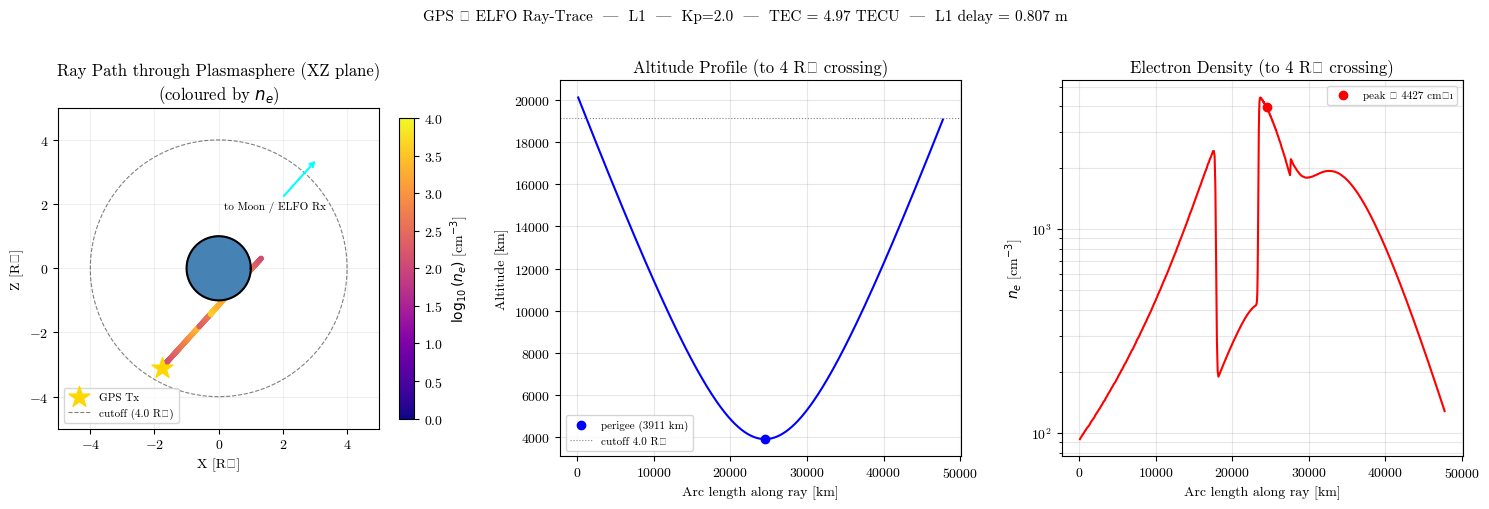

In [8]:
# ── Visualise ray path and density profile ───────────────────────────────────
pos_path = np.array(pp.pos_eci)  # [N_steps x 3] km, ECI (covers the plasma leg)
r_path = np.array(pp.r)  # geocentric distance [km]
s_path = np.array(pp.s)  # arc length [km]

alt_path = r_path - RE_km  # altitude [km]

# Electron density along path (re-compute cheaply at each step)
ne_path = np.array(
    [plasma.compute_ne(epoch_j2000, pos_path[k], config) for k in range(len(s_path))]
)

# Only the segment inside the 4 Rₑ cutoff carries plasma; truncate the profile
# plots there (everything beyond is vacuum out to the Moon). "up to the 4 Rₑ
# crossing" = up to the last sample still within the cutoff radius.
in_plasma = r_path <= config.cutoff_r
k_end = np.max(np.nonzero(in_plasma)) + 1 if in_plasma.any() else len(r_path)
sl = slice(0, k_end)
k_peri = int(np.argmin(r_path[sl]))  # perigee (densest) index

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot A: ray path in XZ plane (near-Earth plasma region) ----------------
ax = axes[0]
sc = ax.scatter(
    pos_path[sl, 0] / RE_km,
    pos_path[sl, 2] / RE_km,
    c=np.log10(np.where(ne_path[sl] > 0, ne_path[sl], np.nan)),
    cmap="plasma",
    s=8,
    vmin=0,
    vmax=4,
    zorder=4,
)
fig.colorbar(sc, ax=ax, label=r"$\log_{10}(n_e)$ [cm$^{-3}$]", shrink=0.8)
ax.scatter(
    *pos_tx_km[[0, 2]] / RE_km,
    marker="*",
    s=250,
    color="gold",
    zorder=10,
    label="GPS Tx",
)
# Earth
ax.fill(np.cos(theta_circ), np.sin(theta_circ), color="steelblue", zorder=5)
ax.plot(np.cos(theta_circ), np.sin(theta_circ), "k-", lw=1.5, zorder=6)
ax.plot(
    CUTOFF_RE * np.cos(theta_circ),
    CUTOFF_RE * np.sin(theta_circ),
    "k--",
    lw=0.8,
    alpha=0.5,
    label=f"cutoff ({CUTOFF_RE} Rₑ)",
)
# Direction to the Moon / ELFO Rx (it sits ~55 Rₑ away, off-plot)
moon_dir = pos_moon_km[[0, 2]] / np.linalg.norm(pos_moon_km[[0, 2]])
ax.annotate(
    "to Moon / ELFO Rx",
    xy=moon_dir * 4.6,
    xytext=moon_dir * 2.6,
    fontsize=8,
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=1.5),
)
LIM = 5.0
ax.set_xlim(-LIM, LIM)
ax.set_ylim(-LIM, LIM)
ax.set_xlabel("X [Rₑ]")
ax.set_ylabel("Z [Rₑ]")
ax.set_title("Ray Path through Plasmasphere (XZ plane)\n(coloured by $n_e$)")
ax.legend(fontsize=8, loc="lower left")
ax.set_aspect("equal")
ax.grid(alpha=0.2)

# --- Plot B: altitude profile (to the 4 Rₑ crossing) ------------------------
ax2 = axes[1]
ax2.plot(s_path[sl], alt_path[sl], "b-", lw=1.5)
ax2.scatter(
    s_path[sl][k_peri],
    alt_path[sl][k_peri],
    color="b",
    zorder=5,
    label=f"perigee ({alt_path[sl][k_peri]:.0f} km)",
)
ax2.axhline(
    (CUTOFF_RE - 1) * RE_km,
    color="gray",
    lw=0.8,
    ls=":",
    label=f"cutoff {CUTOFF_RE} Rₑ",
)
ax2.set_xlabel("Arc length along ray [km]")
ax2.set_ylabel("Altitude [km]")
ax2.set_title("Altitude Profile (to 4 Rₑ crossing)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# --- Plot C: electron density profile (to the 4 Rₑ crossing) ----------------
ax3 = axes[2]
ne_plot = np.where(ne_path[sl] > 0, ne_path[sl], np.nan)
ax3.semilogy(s_path[sl], ne_plot, "r-", lw=1.5)
ax3.scatter(
    s_path[sl][k_peri],
    ne_plot[k_peri],
    color="r",
    zorder=5,
    label=f"peak ≈ {np.nanmax(ne_plot):.0f} cm⁻³",
)
ax3.set_xlabel("Arc length along ray [km]")
ax3.set_ylabel(r"$n_e$ [cm$^{-3}$]")
ax3.set_title("Electron Density (to 4 Rₑ crossing)")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, which="both")

fig.suptitle(
    f"GPS → ELFO Ray-Trace  |  L1  |  Kp={kp:.1f}  |  "
    f"TEC = {pp.tecu:.2f} TECU  |  L1 delay = {pp.total_delay_m:.3f} m",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()

### Why the density profile (Plot C) looks like it has a "jump"

The $n_e$ curve shows two near-vertical walls (a steep drop on the inbound leg and a steep rise back up toward perigee). **These are not a discontinuity or a bug** — they are the real, steep-but-*continuous* gradient across the **plasmapause / inner-plasmasphere boundary** of the GCPM v2.4 model.

Two things make a smooth gradient *look* like a step here:

1. **The arc-length axis is compressed.** The plotted path spans ~0–50 000 km, but each transition is only ~200–400 km wide. On a log-$n_e$ axis, a factor-of-$\sim$10 change over a few hundred km is thinner than a plot pixel, so it renders as a vertical cliff.
2. **The integration step is coarse.** With `config.step_size = 100 km`, only 2–4 samples land inside each transition, connecting the top and bottom with what looks like a single vertical segment.

Resampling the exact same path finely (2 km) shows the walls are in fact **smooth and monotonic**: e.g. across the inbound wall $n_e$ falls from ~2000 to ~330 cm⁻³ over ~230 km, and across the perigee-side wall it rises from ~450 to ~4400 cm⁻³ over ~450 km — no jump, no `NaN`, no sign flip.

The steepness is physical: in `compute_ne` the receiver position is converted to solar-magnetic coordinates with a **continuous** magnetic local time (unlike the hard noon/midnight `amlt` switch used only for the Part 1 *grid*), and every GCPM region boundary (plasmapause, inner-plasmasphere bridge, trough, IRI bridge, polar cap) is blended with a smooth `switchon()` transition — so the field is continuous by construction, just sharp near the plasmapause. The density peak sitting slightly off the geometric perigee is the same effect: the plasma is organized by dipole L-shell and magnetic latitude, not by geocentric radius.

To render it smoothly, reduce `config.step_size` (e.g. to 25 km, at higher compute cost) or zoom the arc-length axis onto the near-Earth plasma leg.